In [1]:
import pandas as pd
import mlflow

In [2]:
from pathlib import Path

DATA_PATH = Path("./Data")
RAW_DATA_PATH = DATA_PATH / "raw" / "Fraud_Data.csv"
PROCESSED_DATA_PATH = DATA_PATH / "processed"

PROCESSED_DATA_PATH.mkdir(parents=True, exist_ok=True)

In [3]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("Fraud Detection") 
mlflow.start_run(run_name="ClassImbalance")

<ActiveRun: >

# Load Data with correct Types

In [4]:
X_train = pd.read_csv(PROCESSED_DATA_PATH / "4.1_X_train.csv")
y_train = pd.read_csv(PROCESSED_DATA_PATH / "4.2_y_train.csv")
X_test = pd.read_csv(PROCESSED_DATA_PATH / "4.3_X_test.csv")
y_test = pd.read_csv(PROCESSED_DATA_PATH / "4.4_y_test.csv")

In [5]:
X_train.head()

,purchase_value,source,browser,sex,age,time_velocity,ip_user_share_count,device_user_share_count,day,hour,...,browser_FireFox,browser_IE,browser_Opera,browser_Safari,sex_F,sex_M,source_fr_enc,browser_fr_enc,source_targ_enc,browser_targ_enc
0,14,Ads,Chrome,F,38,7212744.0,0,0,25,11,...,False,False,False,False,True,False,0.395388,0.406952,0.104356,0.111798
1,14,Ads,Chrome,F,38,1.0,1,1,1,0,...,False,False,False,False,True,False,0.395388,0.406952,0.104356,0.111798
2,14,Ads,Chrome,F,38,1.0,2,2,1,0,...,False,False,False,False,True,False,0.395388,0.406952,0.104356,0.111798
3,14,Ads,Chrome,F,38,1.0,3,3,1,0,...,False,False,False,False,True,False,0.395388,0.406952,0.104356,0.111798
4,14,Ads,Chrome,F,38,1.0,4,4,1,0,...,False,False,False,False,True,False,0.395388,0.406952,0.104356,0.111798


In [6]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120889 entries, 0 to 120888
Data columns (total 26 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   purchase_value                120889 non-null  int64  
 1   source                        120889 non-null  object 
 2   browser                       120889 non-null  object 
 3   sex                           120889 non-null  object 
 4   age                           120889 non-null  int64  
 5   time_velocity                 120889 non-null  float64
 6   ip_user_share_count           120889 non-null  int64  
 7   device_user_share_count       120889 non-null  int64  
 8   day                           120889 non-null  int64  
 9   hour                          120889 non-null  int64  
 10  age_manual_binned             120889 non-null  int64  
 11  purchase_value_manual_binned  120889 non-null  int64  
 12  source_Ads                    120889 non-nul

<Axes: xlabel='class'>

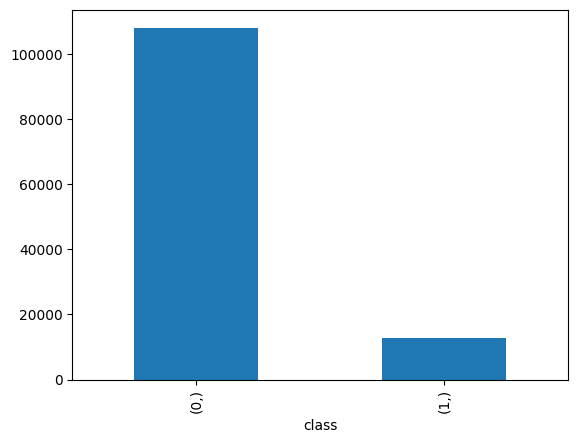

In [7]:
y_train.value_counts().plot(kind="bar")

<Axes: xlabel='class'>

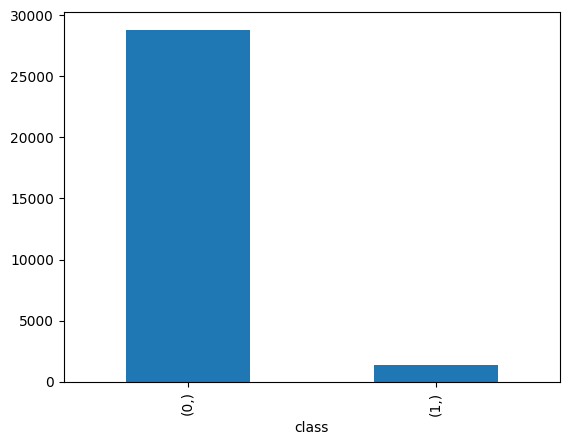

In [8]:
y_test.value_counts().plot(kind="bar")

# SMOTE

In [22]:
from imblearn.over_sampling import SMOTENC

In [23]:
categorical_features = [
    1,2,3, # original categorical cols
    10, 11, 12, 13, 14,  # source # browser
    15, 16, 17, 18, 19            # sex
]

smote = SMOTENC(
    categorical_features=categorical_features,
    random_state=42
)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train,
    y_train
)

<Axes: xlabel='class'>

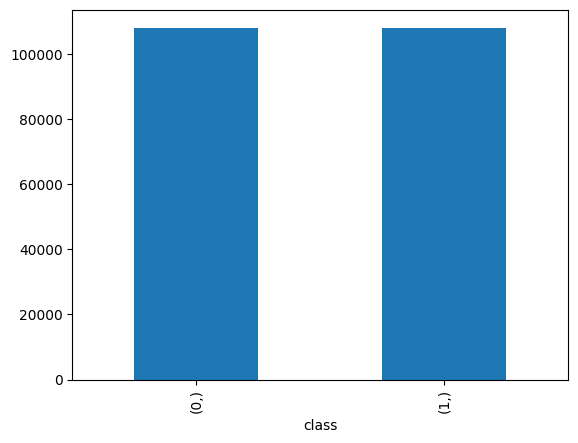

In [24]:
y_train_resampled.value_counts().plot(kind="bar")

# Save CSV

In [25]:
X_train_resampled.to_csv(PROCESSED_DATA_PATH / "5.1_X_train.csv", index=False)
y_train_resampled.to_csv(PROCESSED_DATA_PATH / "5.2_y_train.csv", index=False)


In [14]:
from collections import defaultdict

# Build a string report
report_lines = []
report_lines.append("DataFrame Summary")
report_lines.append("=" * 50) 
report_lines.append("\nSummary of Data Splitting Stage:")
report_lines.append(
"""
 Here I did SMOTE but with the existence of categorical features, I had to use SMOTENC.
 But what we done here not valid at all. This is just done to practice.
 Because when we do the model evaluation, If we use the cross validation, We have to do SMOTE for each fold.
"""
)
report_str = "\n".join(report_lines)

# Log to MLflow (within an active run)
mlflow.log_text(report_str, "cls_imblnc/summary.txt")

In [26]:
mlflow.end_run()

🏃 View run ClassImbalance at: http://localhost:5000/#/experiments/1/runs/59af16db11d54b249d02cb6a81e04bf6
🧪 View experiment at: http://localhost:5000/#/experiments/1
